데이터를 로드하고 위험도를 계산합니다...


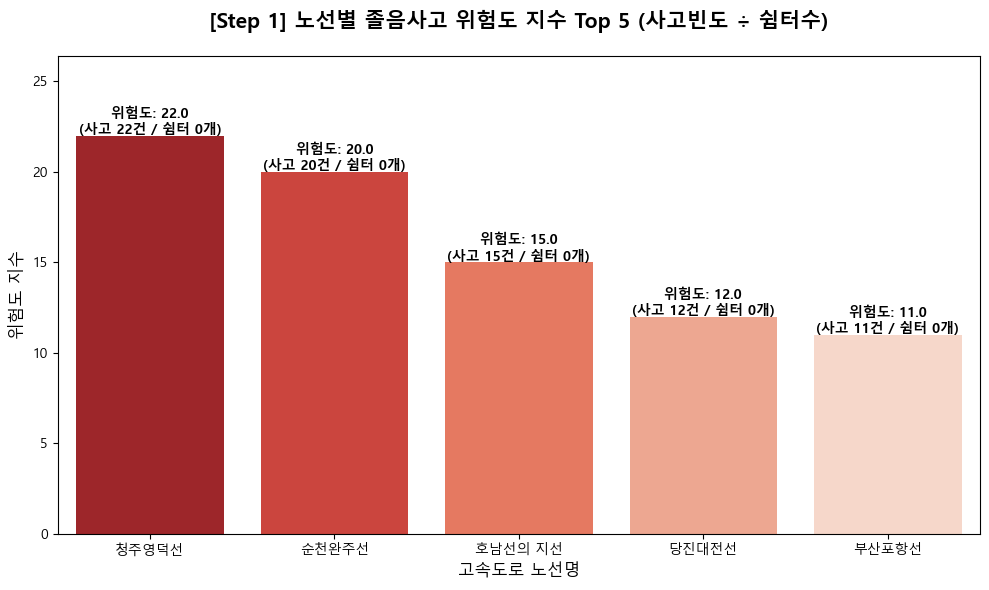


🎯 [고위험군 선정 결과]
   정제노선  사고수  쉼터수  위험도지수
  청주영덕선   22  0.0   22.0
  순천완주선   20  0.0   20.0
호남선의 지선   15  0.0   15.0
  당진대전선   12  0.0   12.0
  부산포항선   11  0.0   11.0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import platform

# 1. 폰트 및 기본 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 💡 사용자님의 로컬 작업 폴더 경로 설정
base_path = r"C:\Project\Python_Source\python311_01\pandas_ex\project_1"

def load_data(filename):
    file_path = os.path.join(base_path, filename)
    encodings = ['cp949', 'utf-8-sig', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except (UnicodeDecodeError, LookupError):
            continue
        except FileNotFoundError:
            print(f"❌ 파일 없음 에러: 폴더에 '{filename}' 파일이 없습니다.")
            return None
    return None

def clean_route_name(name):
    if pd.isna(name): return "기타"
    name = str(name).strip()
    if "(" in name: name = name.split("(")[0].strip() 
    return name

# =====================================================================
# [Step 1] 데이터 로드 및 위험도 지수 계산
# =====================================================================
print("데이터를 로드하고 위험도를 계산합니다...")
acc_ex = load_data("한국도로공사_졸음운전 사고통계(2022~2024).csv") 
shelters = load_data("한국도로공사 졸음쉼터 설치현황(2024년).csv") 

# 노선명 표준화
acc_ex['정제노선'] = acc_ex['노선명'].apply(clean_route_name)
shelters['정제노선'] = shelters['노선'].apply(clean_route_name)

# 사고수 및 쉼터수 집계
acc_route = acc_ex.groupby('정제노선').size().reset_index(name='사고수')
she_route = shelters.groupby('정제노선').size().reset_index(name='쉼터수')

# 데이터 병합
df_risk = pd.merge(acc_route, she_route, on='정제노선', how='left').fillna(0)

# 💡 핵심 공식: 위험도 지수 = 사고빈도 / 쉼터수
# (단, 쉼터가 0개인 노선은 분모가 0이 되어 에러가 나므로, 수학적 계산을 위해 임시로 분모를 1로 처리)
df_risk['계산용_쉼터수'] = df_risk['쉼터수'].replace(0, 1)
df_risk['위험도지수'] = df_risk['사고수'] / df_risk['계산용_쉼터수']

# 고위험군 Top 5 선정
top5_risk = df_risk.sort_values('위험도지수', ascending=False).head(5)

# =====================================================================
# 시각화: 고위험군 Top 5
# =====================================================================
plt.figure(figsize=(10, 6))
sns.barplot(data=top5_risk, x='정제노선', y='위험도지수', hue='정제노선', palette='Reds_r', legend=False)

plt.title('[Step 1] 노선별 졸음사고 위험도 지수 Top 5 (사고빈도 ÷ 쉼터수)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('고속도로 노선명', fontsize=12)
plt.ylabel('위험도 지수', fontsize=12)

# 수치 표시 및 쉼터 개수 표기
for i, row in enumerate(top5_risk.itertuples()):
    # 막대 위에 위험도 수치와 실제 쉼터 개수를 같이 적어줌
    text_label = f"위험도: {row.위험도지수:.1f}\n(사고 {row.사고수}건 / 쉼터 {int(row.쉼터수)}개)"
    plt.text(i, row.위험도지수 + 0.1, text_label, ha='center', fontweight='bold')

plt.ylim(0, top5_risk['위험도지수'].max() * 1.2) # 글자가 잘리지 않게 높이 여백 추가
plt.tight_layout()
plt.show()

print("\n🎯 [고위험군 선정 결과]")
print(top5_risk[['정제노선', '사고수', '쉼터수', '위험도지수']].to_string(index=False))

데이터를 로드하고 공간 밀도 분석을 준비합니다...


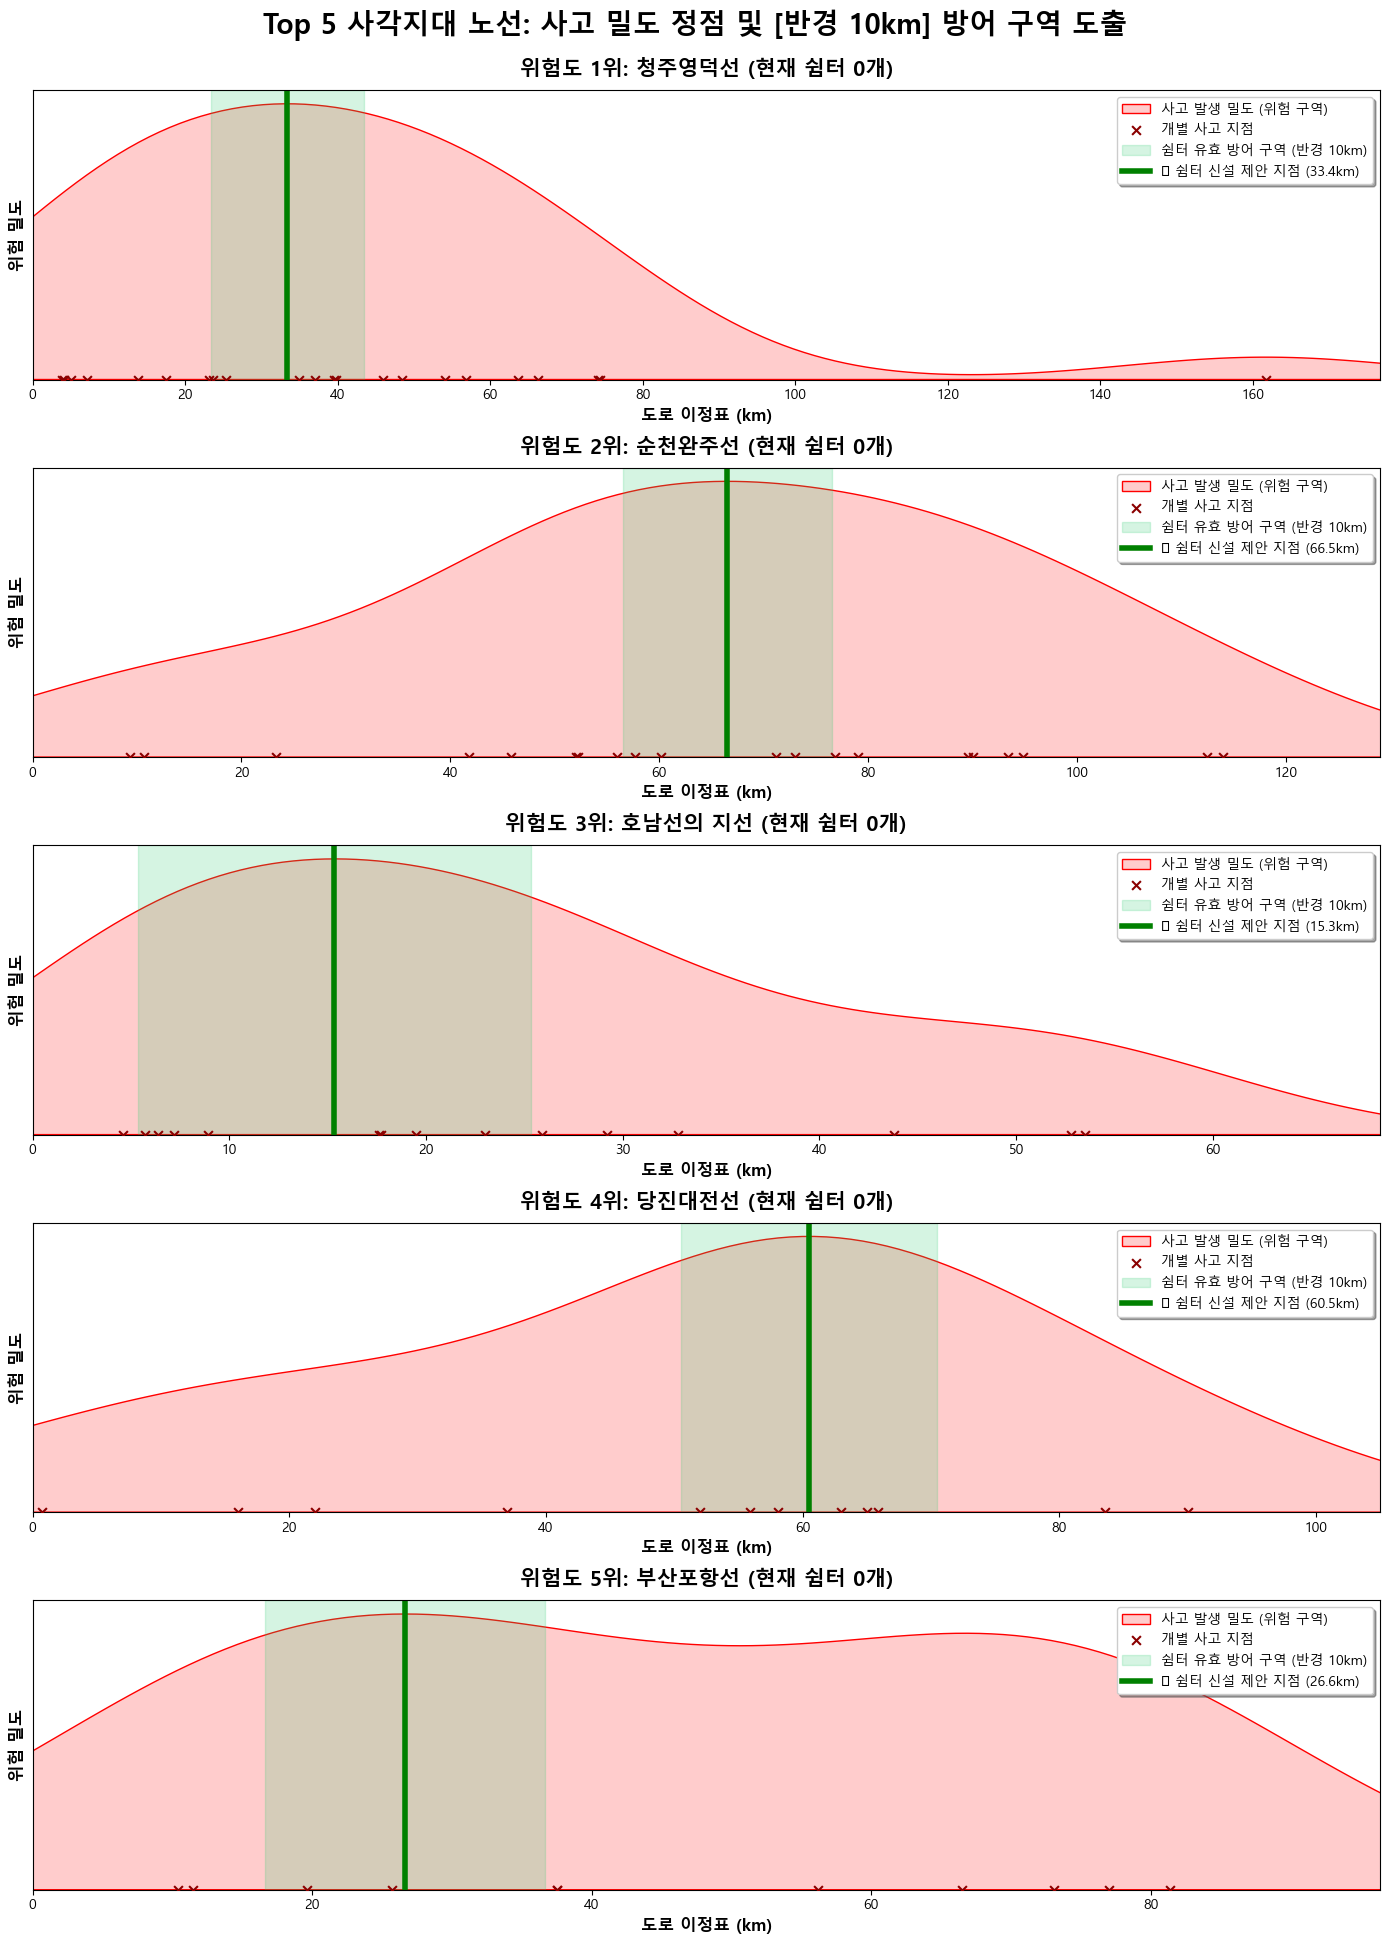


🎯 [공간 분석 완료] 각 노선별 최적 입지 및 10km 방어 반경 시각화 성공!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import platform
from scipy.stats import gaussian_kde
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. 폰트 및 기본 설정
# =====================================================================
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Project\Python_Source\python311_01\pandas_ex\project_1"

def load_data(filename):
    file_path = os.path.join(base_path, filename)
    encodings = ['cp949', 'utf-8-sig', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except:
            continue
    return None

def clean_route_name(name):
    if pd.isna(name): return "기타"
    name = str(name).strip()
    if "(" in name: name = name.split("(")[0].strip() 
    return name

# =====================================================================
# 2. 데이터 로드 및 전처리
# =====================================================================
print("데이터를 로드하고 공간 밀도 분석을 준비합니다...")
acc_ex = load_data("한국도로공사_졸음운전 사고통계(2022~2024).csv") 
shelters = load_data("한국도로공사 졸음쉼터 설치현황(2024년).csv") 

acc_ex['정제노선'] = acc_ex['노선명'].apply(clean_route_name)
shelters['정제노선'] = shelters['노선'].apply(clean_route_name)

# 거리(km) 데이터를 숫자로 변환 (이게 있어야 위치를 찍을 수 있음)
acc_ex['사고발생이정'] = pd.to_numeric(acc_ex['사고발생이정'], errors='coerce')
shelters['이정'] = pd.to_numeric(shelters['이정'], errors='coerce')

# =====================================================================
# 3. [사용자님 공식] Top 5 노선 선정
# =====================================================================
acc_route = acc_ex.groupby('정제노선').size().reset_index(name='사고수')
she_route = shelters.groupby('정제노선').size().reset_index(name='쉼터수')

df_risk = pd.merge(acc_route, she_route, on='정제노선', how='left').fillna(0)
df_risk['계산용_쉼터수'] = df_risk['쉼터수'].replace(0, 1)
df_risk['위험도지수'] = df_risk['사고수'] / df_risk['계산용_쉼터수']

# Top 5 노선명 리스트로 추출
top5_routes = df_risk.sort_values('위험도지수', ascending=False).head(5)['정제노선'].tolist()

# =====================================================================
# 4. [공간 분석] 밀도 추정(KDE) 및 💡 '10km 반경 커버리지' 시각화
# =====================================================================
# 그래프 세로 길이를 넉넉하게(20) 주어 5개가 예쁘게 들어가게 함
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False)
plt.suptitle('Top 5 사각지대 노선: 사고 밀도 정점 및 [반경 10km] 방어 구역 도출', fontsize=20, fontweight='bold', y=0.97)

for i, route in enumerate(top5_routes):
    ax = axes[i]
    
    # 해당 노선 데이터 필터링
    r_acc = acc_ex[(acc_ex['정제노선'] == route)].dropna(subset=['사고발생이정'])
    r_she = shelters[shelters['정제노선'] == route].dropna(subset=['이정'])
    
    # 사고가 2건 이상이어야 밀도(KDE)를 그릴 수 있음
    if len(r_acc) > 1:
        # ① 사고 밀도 시각화 (빨간 산 모양)
        sns.kdeplot(data=r_acc, x='사고발생이정', fill=True, color='red', alpha=0.2, ax=ax, label='사고 발생 밀도 (위험 구역)')
        
        # ② 극대값(사고 밀도가 가장 높은 곳 = 최적 입지) 찾기
        kde = gaussian_kde(r_acc['사고발생이정'])
        x_range = np.linspace(r_acc['사고발생이정'].min() - 5, r_acc['사고발생이정'].max() + 5, 1000)
        kde_vals = kde(x_range)
        peak_idx = np.argmax(kde_vals)
        peak_loc = x_range[peak_idx] # 제안 지점 (km)
        
        # ③ 실제 사고 발생 위치 점 찍기
        ax.scatter(r_acc['사고발생이정'], [0]*len(r_acc), color='darkred', marker='x', s=40, label='개별 사고 지점', zorder=5)
        
        # ④ 💡 핵심: 최적 입지 반경 10km 커버리지 표시 (초록색 투명 박스)
        ax.axvspan(max(0, peak_loc - 10), peak_loc + 10, color='#2ecc71', alpha=0.2, label='쉼터 유효 방어 구역 (반경 10km)')
        
        # ⑤ 최적 입지 중앙선 (굵은 초록선)
        ax.axvline(peak_loc, color='green', linestyle='-', linewidth=4, label=f'⭐ 쉼터 신설 제안 지점 ({peak_loc:.1f}km)')
        
        # ⑥ 기존 쉼터 위치 (파란 점선)
        for loc in r_she['이정']:
            ax.axvline(loc, color='blue', linestyle='--', linewidth=2.5, alpha=0.6)
        if len(r_she) > 0:
            ax.axvline(-1000, color='blue', linestyle='--', linewidth=2.5, alpha=0.6, label='기존 쉼터 (사각지대 밖)') 

        ax.set_title(f'위험도 {i+1}위: {route} (현재 쉼터 {len(r_she)}개)', fontsize=15, fontweight='bold', pad=10)
        ax.set_xlim(max(0, r_acc['사고발생이정'].min()-15), r_acc['사고발생이정'].max()+15)
        ax.set_xlabel('도로 이정표 (km)', fontsize=12, fontweight='bold')
        ax.set_ylabel('위험 밀도', fontsize=12, fontweight='bold')
        ax.set_yticks([]) # y축 숫자는 밀도값이라 의미 없으므로 제거
        ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    else:
        ax.set_title(f'위험도 {i+1}위: {route} - 사고 위치 데이터 부족으로 공간 분석 불가', fontsize=15, fontweight='bold')
        ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.93) # 메인 타이틀 공간 확보
plt.show()

print("\n🎯 [공간 분석 완료] 각 노선별 최적 입지 및 10km 방어 반경 시각화 성공!")